In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import StandardScaler
#from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

## Load and Inspect the data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving economic_indicators.csv to economic_indicators.csv
Saving SampleSubmission (1).csv to SampleSubmission (1).csv
Saving Test (1).csv to Test (1).csv
Saving Train (1).csv to Train (1).csv
Saving VariableDefinitions.txt to VariableDefinitions.txt


In [3]:
# Loading the dataset
train = pd.read_csv('Train (1).csv')
test = pd.read_csv('Test (1).csv')
econ = pd.read_csv('economic_indicators.csv')
sample = pd.read_csv('SampleSubmission (1).csv')
with open('VariableDefinitions.txt', 'r') as file:
    variable_definitions = file.read()
# Display the first few rows of the datasets and their shape
display("Train", train.head(), train.shape, "Test", test.head(), test.shape)

'Train'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


(68654, 16)

'Test'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,2022-07-27,2022-08-03,7,Repeat Loan,575.7,0.300000,597.0
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,2022-11-16,2022-11-23,7,Repeat Loan,0.0,0.000000,0.0
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,2022-08-24,2022-08-31,7,Repeat Loan,207.0,0.025079,208.0
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,2022-11-15,2022-11-22,7,Repeat Loan,1013.7,0.300000,1014.0
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,2022-11-10,2022-11-17,7,Repeat Loan,36.0,0.300000,36.0


(18594, 15)

In [4]:
# Check column types & missing values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           68654 non-null  object 
 1   customer_id                  68654 non-null  int64  
 2   country_id                   68654 non-null  object 
 3   tbl_loan_id                  68654 non-null  int64  
 4   lender_id                    68654 non-null  int64  
 5   loan_type                    68654 non-null  object 
 6   Total_Amount                 68654 non-null  float64
 7   Total_Amount_to_Repay        68654 non-null  float64
 8   disbursement_date            68654 non-null  object 
 9   due_date                     68654 non-null  object 
 10  duration                     68654 non-null  int64  
 11  New_versus_Repeat            68654 non-null  object 
 12  Amount_Funded_By_Lender      68654 non-null  float64
 13  Lender_portion_F

In [14]:
train['target'].value_counts()


,count
target,
0,67396
1,1258


In [15]:
train['target'].value_counts(normalize=True)*100


,proportion
target,
0,98.167623
1,1.832377


In [16]:
train.nunique()

,0
ID,68654
customer_id,6540
country_id,1
tbl_loan_id,66520
lender_id,4
loan_type,22
Total_Amount,19076
Total_Amount_to_Repay,21920
disbursement_date,768
due_date,893


The dataset is highly imbalanced with only 1.83% of loans classified as defaults. Therefore, accuracy alone would be misleading, and F1-score is more appropriate for evaluating the model.

In [17]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


Customer history

In [18]:
customer_counts = train["customer_id"].value_counts()
customer_counts.describe()

,count
count,6540.000000
mean,10.497554
std,12.977429
min,1.000000
25%,2.000000
50%,6.000000
75%,14.000000
max,208.000000


In [19]:
customer_counts.head()

,count
customer_id,
247613,208
250874,192
259757,135
255356,128
249457,119


New vs Repeat

In [20]:
pd.crosstab(
    train["New_versus_Repeat"],
    train["target"],
    normalize="index"
)*100

target,0,1
New_versus_Repeat,,
New Loan,79.012346,20.987654
Repeat Loan,98.327140,1.672860


Lender default rates

In [21]:
pd.crosstab(
    train["lender_id"],
    train["target"],
    normalize="index"
)*100

target,0,1
lender_id,,
245684,58.510638,41.489362
251804,91.078487,8.921513
267277,70.479705,29.520295
267278,98.787373,1.212627


Loan type default rates

In [22]:
loan_type_default =(
    train.groupby("loan_type")["target"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)
loan_type_default

,count,mean
loan_type,,
Type_15,4,0.750000
Type_23,18,0.722222
Type_14,99,0.717172
Type_2,74,0.608108
Type_20,13,0.538462
Type_9,205,0.175610
Type_4,1235,0.123077
Type_6,357,0.106443
Type_7,2790,0.084229


Datetime

In [23]:
eda = train.copy()

eda["disbursement_date"] = pd.to_datetime(
    eda["disbursement_date"]
)

eda["due_date"] = pd.to_datetime(
    eda["due_date"]
)

In [25]:
eda[[
    "disbursement_date",
    "due_date"
]].describe()

,disbursement_date,due_date
count,68654,68654
mean,2022-10-17 07:55:03.417135360,2022-10-25 20:59:15.638418944
min,2021-10-04 00:00:00,2021-10-21 00:00:00
25%,2022-08-10 00:00:00,2022-08-17 00:00:00
50%,2022-09-16 00:00:00,2022-09-23 00:00:00
75%,2022-10-24 00:00:00,2022-10-31 00:00:00
max,2024-11-14 00:00:00,2025-10-27 00:00:00


In [26]:
eda["calculated_duration"] = (
    eda["due_date"] - eda["disbursement_date"]
).dt.days

In [27]:
eda["duration_difference"] = (
    eda["calculated_duration"] - eda["duration"]
)

eda["duration_difference"].describe()

,duration_difference
count,68654.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [28]:
(eda["duration_difference"] != 0).sum()

np.int64(0)

Monetary relationships

In [29]:
eda["repayment_extra"] = (
    eda["Total_Amount_to_Repay"]
    - eda["Total_Amount"]
)

eda["repayment_ratio"] = (
    eda["Total_Amount_to_Repay"]
    / eda["Total_Amount"]
)

In [30]:
eda[
    ["Total_Amount",
     "Total_Amount_to_Repay",
     "repayment_extra",
     "repayment_ratio"]
].describe()

,Total_Amount,Total_Amount_to_Repay,repayment_extra,repayment_ratio
count,6.865400e+04,6.865400e+04,6.865400e+04,68654.000000
mean,1.483683e+04,1.563993e+04,8.031013e+02,1.021674
std,1.416499e+05,1.650784e+05,2.646663e+04,0.055723
min,2.000000e+00,0.000000e+00,-4.551185e+04,0.000000
25%,2.295000e+03,2.329000e+03,0.000000e+00,1.000000
50%,5.249000e+03,5.325000e+03,3.300000e+01,1.008157
75%,1.145000e+04,1.165000e+04,1.730000e+02,1.030409
max,2.300000e+07,2.541500e+07,4.748939e+06,3.164865


In [5]:
# Missing values in the train dataset
print(f"There are {train.isna().sum().sum()} missing values in the data.")

There are 0 missing values in the data.


### EDA

In [6]:
def plot_continuous(df, column, transform=None):
    """
    Plots visualizations for a continuous variable, showing the distribution and boxplot for both
    the original and transformed versions of the data.

    Args:
        df (pandas.DataFrame): The DataFrame containing the data.
        column (str): The column name of the continuous variable to plot.
        transform (str, optional): Transformation to apply to the data before plotting.
                                  Accepted values are 'log' or 'sqrt'. Default is None, which means no transformation.

    This function generates:
        - A histogram with a kernel density estimate (KDE) for the original data.
        - A boxplot for the original data.
        - If a transformation is specified ('log' or 'sqrt'):
            - A histogram with a KDE for the transformed data.
            - A boxplot for the transformed data.
    """
    # Create subplots for visualizations
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))

    # Original data plots
    sns.histplot(df[column], kde=True, ax=axs[0, 0])
    axs[0, 0].set_title(f'Distribution of {column}')
    axs[0, 0].set_xlabel(column)

    sns.boxplot(y=df[column], ax=axs[1, 0])
    axs[1, 0].set_title(f'Box Plot of {column}')
    axs[1, 0].set_ylabel(column)

    # Transformations (log or square root)
    if transform == 'log':
        transformed_data = np.log1p(df[column])  # log1p handles log(0) gracefully
        transform_label = 'Log'
    elif transform == 'sqrt':
        transformed_data = np.sqrt(df[column])  # Square root transformation
        transform_label = 'Square Root'
    else:
        transformed_data = None  # No transformation if not specified

    # If transformed data exists, generate corresponding plots
    if transformed_data is not None:
        sns.histplot(transformed_data, kde=True, ax=axs[0, 1])
        axs[0, 1].set_title(f'{transform_label} Distribution of {column}')
        axs[0, 1].set_xlabel(f'{transform_label}({column})')

        sns.boxplot(y=transformed_data, ax=axs[1, 1])
        axs[1, 1].set_title(f'{transform_label} Box Plot of {column}')
        axs[1, 1].set_ylabel(f'{transform_label}({column})')
    else:
        # If no transformation, remove the second set of axes
        for ax in [axs[0, 1], axs[1, 1]]:
            ax.remove()

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()


def plot_categorical(df, column):
    """
    Plots visualizations for a categorical variable, including a bar plot and a pie chart.

    Args:
        df (pandas.DataFrame): The DataFrame containing the data.
        column (str): The column name of the categorical variable to plot.

    This function generates:
        - A bar plot showing the counts of each category in the specified column.
        - A pie chart showing the relative proportions of each category.
    """
    # Create subplots for visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Bar plot showing counts of each category
    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax1)
    ax1.set_title(f'Bar Plot of {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

    # Pie chart showing percentage distribution of each category
    ax2.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    ax2.set_title(f'Pie Chart of {column}')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()


#### Categorical exploration

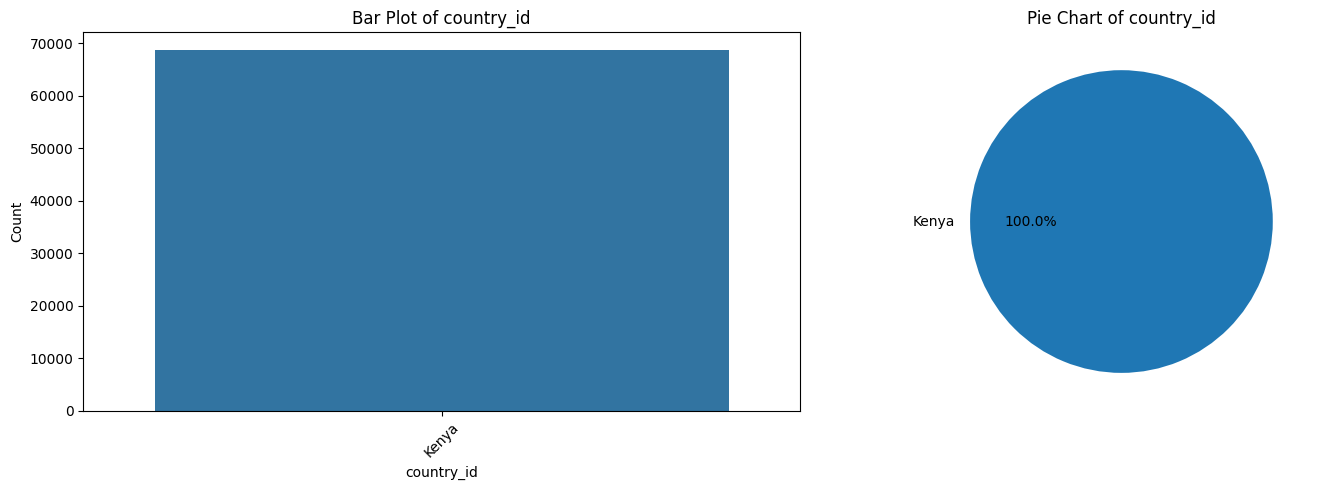

In [7]:
plot_categorical(train, 'country_id')

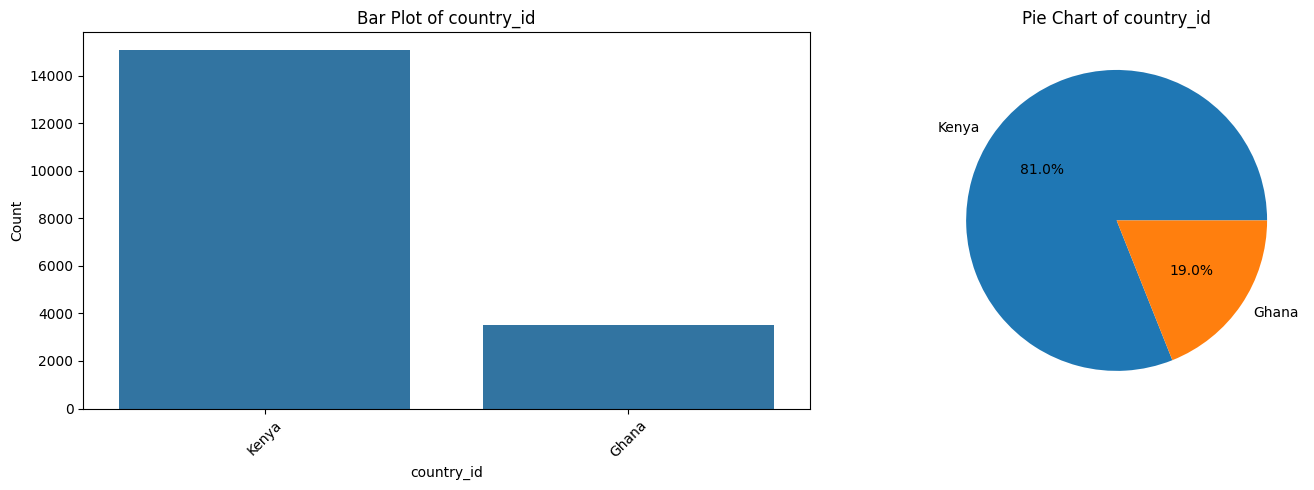

In [8]:
plot_categorical(test, 'country_id')

##### This shows that test has a new country, ghana so one of the goals is to build a solution that can generalize well in new regions

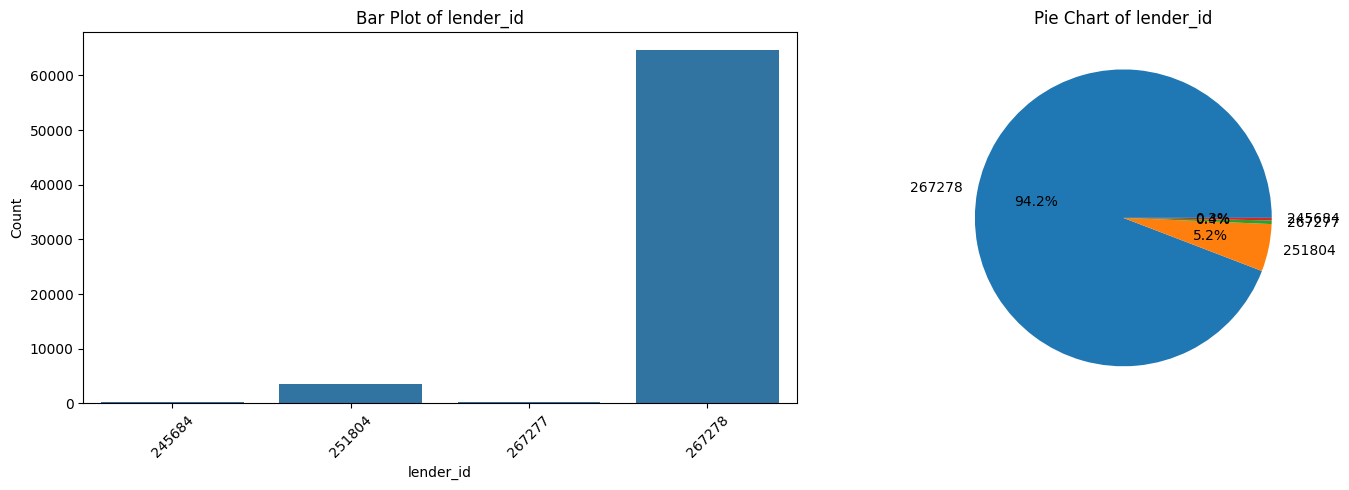

In [9]:
plot_categorical(train, 'lender_id')

#### TARGET EXPLORATION


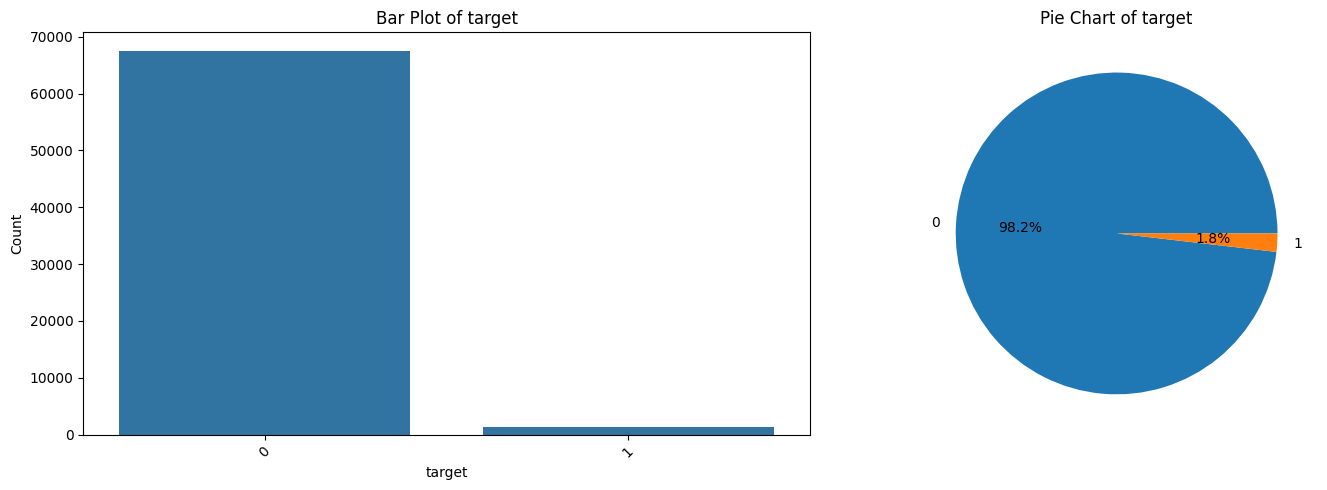

In [10]:
plot_categorical(train, 'target')

##### The dataset is highly imbalanced , and this is expected in loan default scenarios, shall deal with the  imbalance

### CONTINUOUS COLUMN EXPLORATION

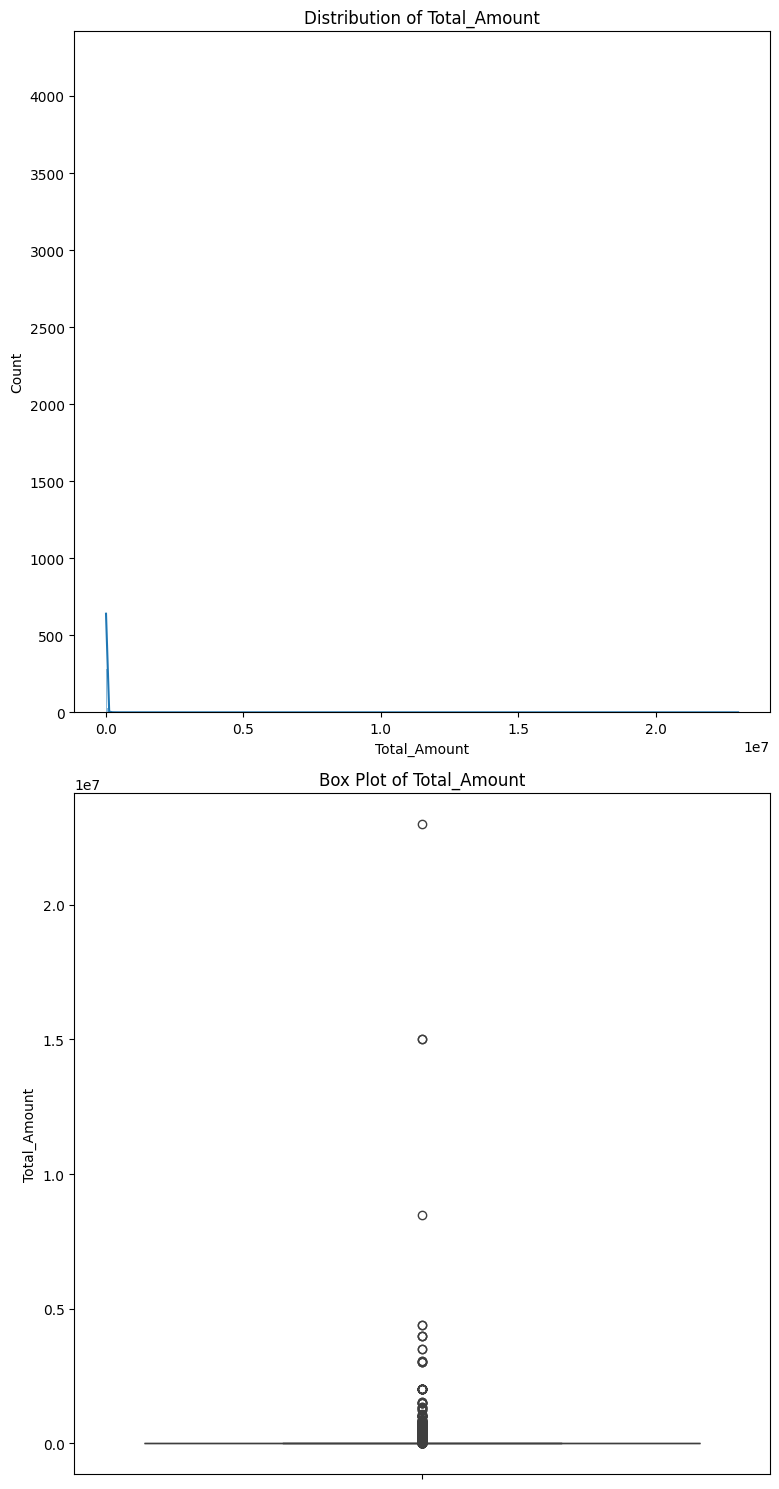

In [11]:
plot_continuous(train, 'Total_Amount')

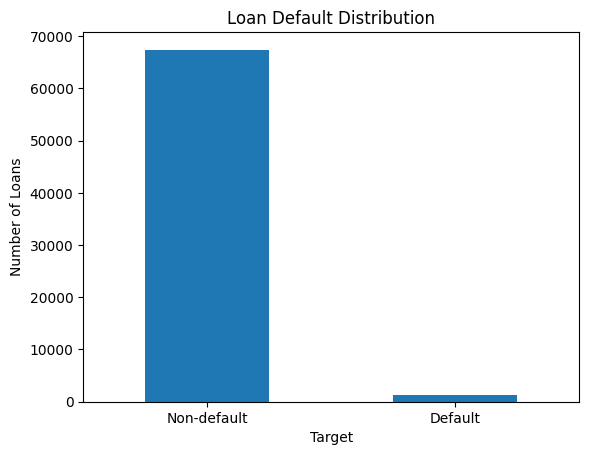

In [31]:
import matplotlib.pyplot as plt

train["target"].value_counts().plot(
    kind="bar"
)

plt.title("Loan Default Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Loans")
plt.xticks(
    [0, 1],
    ["Non-default", "Default"],
    rotation=0
)
plt.show()

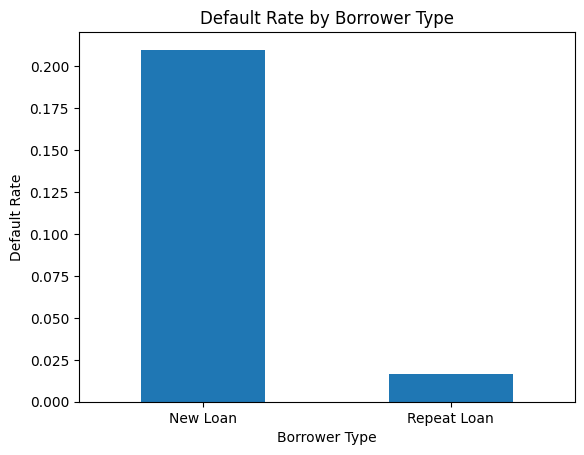

In [32]:
default_by_borrower = (
    train.groupby("New_versus_Repeat")["target"]
    .mean()
    .sort_values(ascending=False)
)

default_by_borrower.plot(kind="bar")

plt.title("Default Rate by Borrower Type")
plt.xlabel("Borrower Type")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

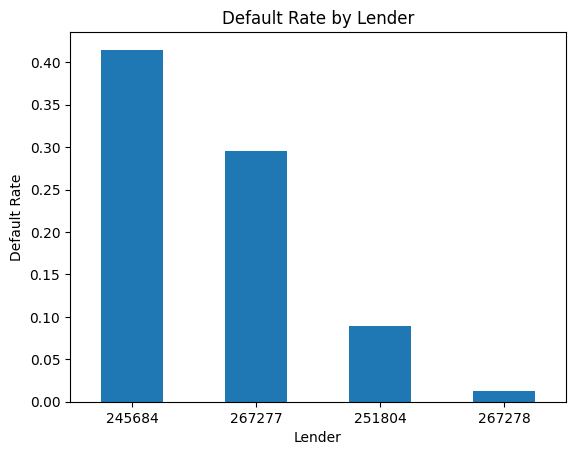

In [33]:
default_by_lender = (
    train.groupby("lender_id")["target"]
    .mean()
    .sort_values(ascending=False)
)

default_by_lender.plot(kind="bar")

plt.title("Default Rate by Lender")
plt.xlabel("Lender")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

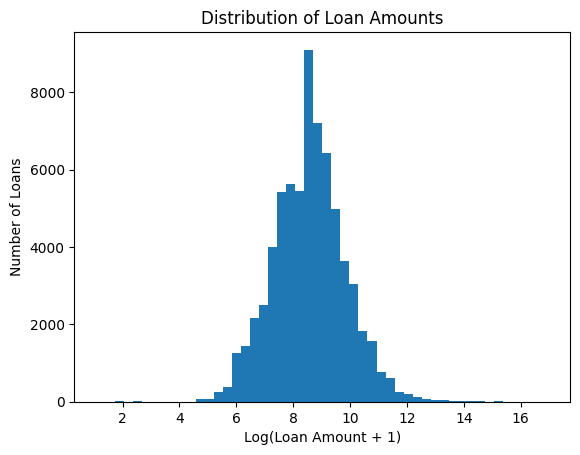

In [34]:
import numpy as np

plt.hist(
    np.log1p(train["Total_Amount"]),
    bins=50
)

plt.title("Distribution of Loan Amounts")
plt.xlabel("Log(Loan Amount + 1)")
plt.ylabel("Number of Loans")
plt.show()

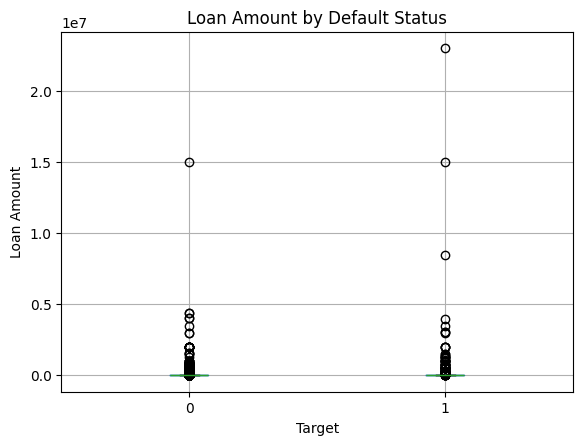

In [35]:
train.boxplot(
    column="Total_Amount",
    by="target"
)

plt.title("Loan Amount by Default Status")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Loan Amount")
plt.show()

In [36]:
train.groupby("target")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,67396.0,8.198424,11.206779,1.0,7.0,7.0,7.0,1096.0
1,1258.0,27.089825,51.376803,7.0,7.0,7.0,30.0,366.0


Defaulting loans have a higher average duration, although the median duraion duration is 7 days for both groups

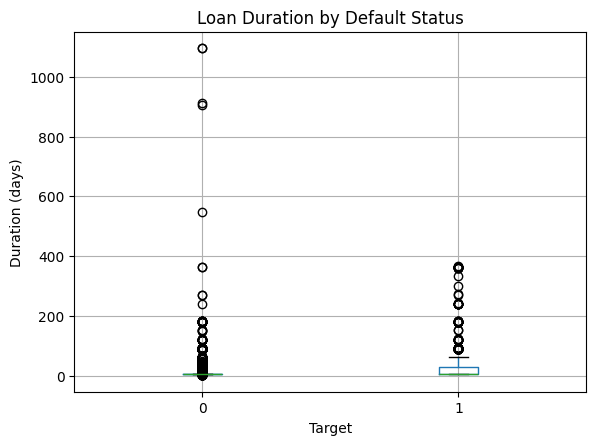

In [37]:
train.boxplot(
    column="duration",
    by="target"
)

plt.title("Loan Duration by Default Status")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Duration (days)")
plt.show()

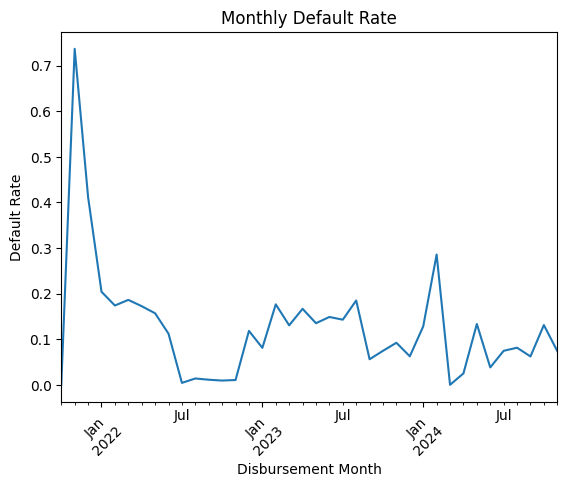

In [39]:
eda["month"] = eda["disbursement_date"].dt.to_period("M")

monthly_default = (
    eda.groupby("month")["target"]
    .mean()
)

monthly_default.plot()

plt.title("Monthly Default Rate")
plt.xlabel("Disbursement Month")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

The EDA revealed subtsantial variation in default risk across borrower history and lending institutions, motivating the use of ml to combine these signals.

In [40]:
monthly_stats = (
    eda.groupby("month")["target"]
    .agg(["count", "sum", "mean"])
)

monthly_stats.sort_values("mean", ascending=False).head(10)

,count,sum,mean
month,,,
2021-11,19,14,0.736842
2021-12,17,7,0.411765
2024-02,14,4,0.285714
2022-01,49,10,0.204082
2022-03,306,57,0.186275
2023-08,146,27,0.184932
2023-02,102,18,0.176471
2022-02,230,40,0.173913
2022-04,145,25,0.172414


Default rates vary overtime, but extreme monthly rates are unreliable when the number of loans is small.

### Feature Engineering


In [41]:
print("Zero repayment:",
      (eda["Total_Amount_to_Repay"] == 0).sum())

print("Zero loan amount:",
      (eda["Total_Amount"] == 0).sum())

print("Repayment less than loan:",
      (eda["Total_Amount_to_Repay"] < eda["Total_Amount"]).sum())

Zero repayment: 3
Zero loan amount: 0
Repayment less than loan: 72


In [42]:
eda.loc[
    eda["Total_Amount_to_Repay"] == 0,
    [
        "customer_id",
        "tbl_loan_id",
        "Total_Amount",
        "Total_Amount_to_Repay",
        "loan_type",
        "duration",
        "target"
    ]
]

,customer_id,tbl_loan_id,Total_Amount,Total_Amount_to_Repay,loan_type,duration,target
14942,259525,295227,2259.0,0.0,Type_1,7,0
46044,248700,232519,500.0,0.0,Type_13,30,0
58838,262903,231904,290.0,0.0,Type_1,7,0


In [43]:
eda.loc[
    eda["Total_Amount_to_Repay"] < eda["Total_Amount"],
    [
        "customer_id",
        "tbl_loan_id",
        "Total_Amount",
        "Total_Amount_to_Repay",
        "repayment_extra",
        "loan_type",
        "target"
    ]
].head(20)

,customer_id,tbl_loan_id,Total_Amount,Total_Amount_to_Repay,repayment_extra,loan_type,target
70,260863,236259,949.00,932.00,-17.00,Type_1,0
726,259843,306527,246150.00,207624.25,-38525.75,Type_10,0
911,271535,263157,300.00,299.50,-0.50,Type_5,0
1763,256566,235585,870.00,857.00,-13.00,Type_1,0
3843,267330,230417,7497.00,6327.00,-1170.00,Type_1,0
5651,241346,236789,1180.00,1024.00,-156.00,Type_1,0
8692,245234,236074,1300.00,1291.00,-9.00,Type_1,0
9127,251142,230435,6249.00,5051.00,-1198.00,Type_1,0
9175,270581,256924,1000.00,793.00,-207.00,Type_1,0
9652,264732,236574,216.00,169.00,-47.00,Type_1,0


In [44]:
duplicate_loan_counts = (
    train.groupby("tbl_loan_id")
    .size()
    .sort_values(ascending=False)
)

duplicate_loan_counts.head(20)

,0
tbl_loan_id,
357502,2
357504,2
357505,2
357506,2
357516,2
357522,2
357523,2
357527,2
357528,2


In [45]:
print("Number of loan IDs appearing more than once:",
      (duplicate_loan_counts > 1).sum())

Number of loan IDs appearing more than once: 2134


Although tbl_loan_id was described as a unique loan identifier, 2134 IDs occurred twicw in the training data. These are retained pending investigation because the correspoding rows were not exact duplicates

In [46]:
train[train["tbl_loan_id"] == 357502].T

,9159,51891
ID,ID_259206357502267278,ID_259206357502251804
customer_id,259206,259206
country_id,Kenya,Kenya
tbl_loan_id,357502,357502
lender_id,267278,251804
loan_type,Type_10,Type_10
Total_Amount,550748.0,550748.0
Total_Amount_to_Repay,559096.16,559096.16
disbursement_date,2023-08-02,2023-08-02
due_date,2023-09-15,2023-09-15


In [47]:
train[
    train["tbl_loan_id"].isin(
        duplicate_loan_counts[duplicate_loan_counts > 1].index
    )
]["target"].value_counts()

,count
target,
0,3914
1,354


In [48]:
train[
    train["tbl_loan_id"].isin(
        duplicate_loan_counts[duplicate_loan_counts > 1].index
    )
].groupby("tbl_loan_id")["target"].nunique().value_counts()

,count
target,
1,2132
2,2


In [49]:
target_conflicts = (
    train.groupby("tbl_loan_id")["target"]
    .nunique()
)

conflicting_loans = target_conflicts[
    target_conflicts > 1
].index

print(conflicting_loans)

Index([360454, 360498], dtype='int64', name='tbl_loan_id')


In [50]:
train[
    train["tbl_loan_id"].isin(conflicting_loans)
].T

,28447,41354,47892,61141
ID,ID_272181360498267278,ID_272181360498251804,ID_271519360454251804,ID_271519360454267278
customer_id,272181,272181,271519,271519
country_id,Kenya,Kenya,Kenya,Kenya
tbl_loan_id,360498,360498,360454,360454
lender_id,267278,251804,251804,267278
loan_type,Type_4,Type_4,Type_4,Type_4
Total_Amount,3500000.0,3500000.0,2000000.0,2000000.0
Total_Amount_to_Repay,3984176.0,3984176.0,2276000.0,2276000.0
disbursement_date,2023-11-07,2023-11-07,2023-11-02,2023-11-02
due_date,2024-05-05,2024-05-05,2024-04-30,2024-04-30


In [51]:
model_df = train.copy()

model_df["disbursement_date"] = pd.to_datetime(
    model_df["disbursement_date"]
)

model_df["due_date"] = pd.to_datetime(
    model_df["due_date"]
)

financial features

In [52]:
model_df["repayment_extra"] = (
    model_df["Total_Amount_to_Repay"]
    - model_df["Total_Amount"]
)

model_df["repayment_ratio"] = (
    model_df["Total_Amount_to_Repay"]
    / model_df["Total_Amount"]
)

time features

In [53]:
model_df["disbursement_month"] = (
    model_df["disbursement_date"].dt.month
)

model_df["disbursement_year"] = (
    model_df["disbursement_date"].dt.year
)

In [54]:
drop_cols = [
    "ID",
    "customer_id",
    "country_id",
    "tbl_loan_id",
    "disbursement_date",
    "due_date",
    "target"
]

X = model_df.drop(columns=drop_cols)
y = model_df["target"]

In [55]:
print(X.shape)
print(X.columns.tolist())

(68654, 13)
['lender_id', 'loan_type', 'Total_Amount', 'Total_Amount_to_Repay', 'duration', 'New_versus_Repeat', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'repayment_extra', 'repayment_ratio', 'disbursement_month', 'disbursement_year']


In [58]:
X.dtypes

,0
lender_id,int64
loan_type,object
Total_Amount,float64
Total_Amount_to_Repay,float64
duration,int64
New_versus_Repeat,object
Amount_Funded_By_Lender,float64
Lender_portion_Funded,float64
Lender_portion_to_be_repaid,float64
repayment_extra,float64


OneHot encode categorical values

In [59]:
categorical_features = [
    "lender_id",
    "loan_type",
    "New_versus_Repeat"
]

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (54923, 13)
Validation: (13731, 13)


preprocessing

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = [
    "lender_id",
    "loan_type",
    "New_versus_Repeat"
]

numeric_features = [
    "Total_Amount",
    "Total_Amount_to_Repay",
    "duration",
    "Amount_Funded_By_Lender",
    "Lender_portion_Funded",
    "Lender_portion_to_be_repaid",
    "repayment_extra",
    "repayment_ratio",
    "disbursement_month",
    "disbursement_year"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

Starting with logistic regression

In [62]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

In [64]:
logistic_model.fit(X_train, y_train)
pred = logistic_model.predict(X_val)

In [65]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

pred = logistic_model.predict(X_val)

print("F1:", f1_score(y_val, pred))
print("Precision:", precision_score(y_val, pred))
print("Recall:", recall_score(y_val, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, pred))

print("\nClassification Report:")
print(classification_report(y_val, pred))

F1: 0.3620178041543027
Precision: 0.22262773722627738
Recall: 0.9682539682539683

Confusion Matrix:
[[12627   852]
 [    8   244]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     13479
           1       0.22      0.97      0.36       252

    accuracy                           0.94     13731
   macro avg       0.61      0.95      0.66     13731
weighted avg       0.99      0.94      0.96     13731



In [66]:
val_probabilities = logistic_model.predict_proba(X_val)[:, 1]

In [67]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds:
    threshold_pred = (
        val_probabilities >= threshold
    ).astype(int)

    f1 = f1_score(y_val, threshold_pred)

    results.append({
        "threshold": threshold,
        "f1": f1
    })

threshold_results = pd.DataFrame(results)

best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print(best_row)

threshold    0.920000
f1           0.685246
Name: 87, dtype: float64


In [68]:
best_threshold = best_row["threshold"]

optimized_pred = (
    val_probabilities >= best_threshold
).astype(int)

print("Optimized F1:",
      f1_score(y_val, optimized_pred))

print("Precision:",
      precision_score(y_val, optimized_pred))

print("Recall:",
      recall_score(y_val, optimized_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, optimized_pred))

Optimized F1: 0.6852459016393443
Precision: 0.5837988826815642
Recall: 0.8293650793650794

Confusion Matrix:
[[13330   149]
 [   43   209]]


Logistic regression baseline: F1= 0.685 at threshold = 0.92

Random Forest

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            max_depth=None,
            min_samples_leaf=2
        )
    )
])

rf_model.fit(X_train, y_train)

rf_probabilities = rf_model.predict_proba(X_val)[:, 1]

In [70]:
rf_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    rf_pred = (
        rf_probabilities >= threshold
    ).astype(int)

    rf_f1 = f1_score(y_val, rf_pred)

    rf_results.append({
        "threshold": threshold,
        "f1": rf_f1
    })

rf_results = pd.DataFrame(rf_results)

rf_best = rf_results.loc[
    rf_results["f1"].idxmax()
]

print("Best threshold:", rf_best["threshold"])
print("Best F1:", rf_best["f1"])

Best threshold: 0.6400000000000001
Best F1: 0.8502024291497976


In [71]:
rf_best_threshold = rf_best["threshold"]

rf_optimized_pred = (
    rf_probabilities >= rf_best_threshold
).astype(int)

print("F1:",
      f1_score(y_val, rf_optimized_pred))

print("Precision:",
      precision_score(y_val, rf_optimized_pred))

print("Recall:",
      recall_score(y_val, rf_optimized_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_optimized_pred))

F1: 0.8502024291497976
Precision: 0.8677685950413223
Recall: 0.8333333333333334

Confusion Matrix:
[[13447    32]
 [   42   210]]


X-GBoost

In [72]:
import xgboost

print(xgboost.__version__)

3.3.0


In [73]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Total_Amount',
                                                   'Total_Amount_to_Repay',
                                                   'duration',
                                                   'Amount_Funded_By_Lender',
                                                   'Lender_portion_Funded',
                                                   'Lender_portion_to_be_repaid',
                                                   'repayment_extra',
                                                   'repayment_ratio',
                                                   'disbursement_month',
                                                   'disbursement_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['lend...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [74]:
xgb_probabilities = xgb_model.predict_proba(X_val)[:, 1]

In [75]:
xgb_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    xgb_pred = (
        xgb_probabilities >= threshold
    ).astype(int)

    xgb_f1 = f1_score(y_val, xgb_pred)

    xgb_results.append({
        "threshold": threshold,
        "f1": xgb_f1
    })

xgb_results = pd.DataFrame(xgb_results)

xgb_best = xgb_results.loc[
    xgb_results["f1"].idxmax()
]

print("Best threshold:", xgb_best["threshold"])
print("Best F1:", xgb_best["f1"])

Best threshold: 0.5500000000000002
Best F1: 0.8507157464212679


In [76]:
xgb_best_threshold = xgb_best["threshold"]

xgb_optimized_pred = (
    xgb_probabilities >= xgb_best_threshold
).astype(int)

print("F1:",
      f1_score(y_val, xgb_optimized_pred))

print("Precision:",
      precision_score(y_val, xgb_optimized_pred))

print("Recall:",
      recall_score(y_val, xgb_optimized_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, xgb_optimized_pred))

F1: 0.8507157464212679
Precision: 0.8776371308016878
Recall: 0.8253968253968254

Confusion Matrix:
[[13450    29]
 [   44   208]]


Started with Logistic Regression as a baseline, then evaluated nonlinear tree-based models. Logistic Regression achieved an F1-score of 0.685 after threshold optimization. Random Forest improved this to 0.850, while XGBoost achieved 0.851. The tree-based models outperformed the linear baseline.

Feature Importance

In [77]:
feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    xgb_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
7,num__repayment_ratio,0.255799
30,cat__loan_type_Type_4,0.206152
14,cat__loan_type_Type_1,0.075770
33,cat__loan_type_Type_7,0.065874
6,num__repayment_extra,0.052340
16,cat__loan_type_Type_11,0.042826
9,num__disbursement_year,0.031959
2,num__duration,0.028366
31,cat__loan_type_Type_5,0.027969
3,num__Amount_Funded_By_Lender,0.027063


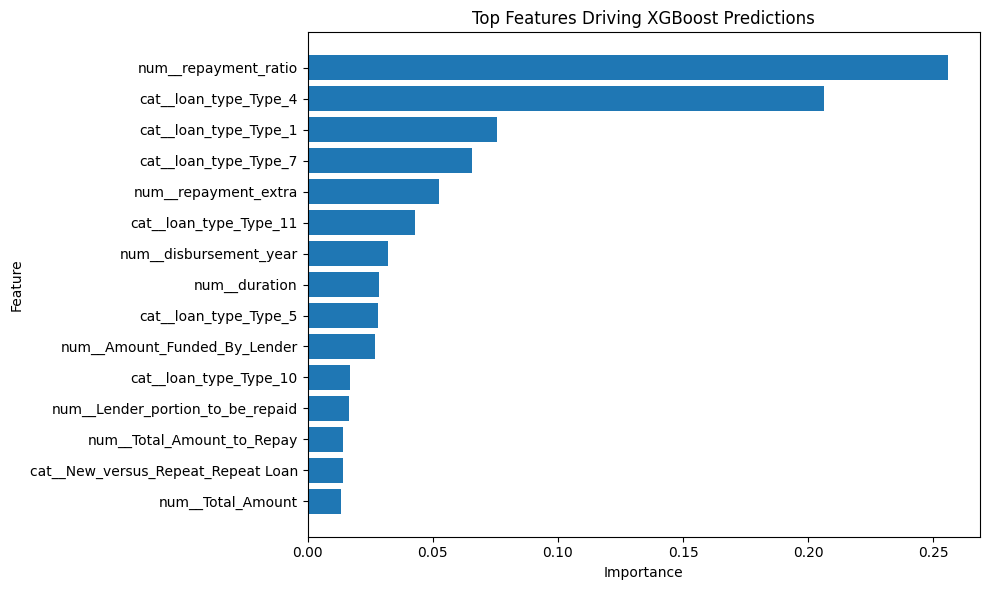

In [78]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Driving XGBoost Predictions")
plt.tight_layout()
plt.show()

Repayment ratio is the most predictive feature in the XGBoost model

### CROSS VALIDATION
* Here we are going to use a simple train test split but due to the imbalance try other robust methods like StratifiedKFold


In [80]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())

F1 scores: [0.83575884 0.85080645 0.85355649 0.8375     0.84566596]
Mean F1: 0.8446575469344839
Std F1: 0.007048894570191977


XGBoost demonstrated stable performance across five stratified folds, achieving a mean F1-score of 0.845 ± 0.007. On our held-out validation set, threshold optimization produced an F1-score of 0.851 at a threshold of 0.55.

In [81]:
final_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

final_xgb_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Total_Amount',
                                                   'Total_Amount_to_Repay',
                                                   'duration',
                                                   'Amount_Funded_By_Lender',
                                                   'Lender_portion_Funded',
                                                   'Lender_portion_to_be_repaid',
                                                   'repayment_extra',
                                                   'repayment_ratio',
                                                   'disbursement_month',
                                                   'disbursement_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['lend...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [82]:
test_model = test.copy()

test_model["disbursement_date"] = pd.to_datetime(
    test_model["disbursement_date"]
)

test_model["due_date"] = pd.to_datetime(
    test_model["due_date"]
)

test_model["repayment_extra"] = (
    test_model["Total_Amount_to_Repay"]
    - test_model["Total_Amount"]
)

test_model["repayment_ratio"] = (
    test_model["Total_Amount_to_Repay"]
    / test_model["Total_Amount"]
)

test_model["disbursement_month"] = (
    test_model["disbursement_date"].dt.month
)

test_model["disbursement_year"] = (
    test_model["disbursement_date"].dt.year
)

In [83]:
X_test = test_model[X.columns]

In [84]:
print(X_test.shape)
print(X_test.columns.tolist())

(18594, 13)
['lender_id', 'loan_type', 'Total_Amount', 'Total_Amount_to_Repay', 'duration', 'New_versus_Repeat', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'repayment_extra', 'repayment_ratio', 'disbursement_month', 'disbursement_year']


In [86]:
test_probabilities = final_xgb_model.predict_proba(X_test)[:, 1]

In [87]:
test_predictions = (
    test_probabilities >= 0.55
).astype(int)

In [88]:
print(pd.Series(test_predictions).value_counts())

0    17948
1      646
Name: count, dtype: int64


Submission

In [89]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "target": test_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print(submission.shape)
print(submission.isna().sum())
print(submission["target"].value_counts())

                      ID  target
0  ID_269404226088267278       0
1  ID_255356300042267278       0
2  ID_257026243764267278       0
3  ID_264617299409267278       0
4  ID_247613296713267278       0
(18594, 2)
ID        0
target    0
dtype: int64
target
0    17948
1      646
Name: count, dtype: int64


In [90]:
import os

print(os.path.exists("submission.csv"))
print(os.path.getsize("submission.csv"))

True
446084
